(30, 244, 244) (30,)


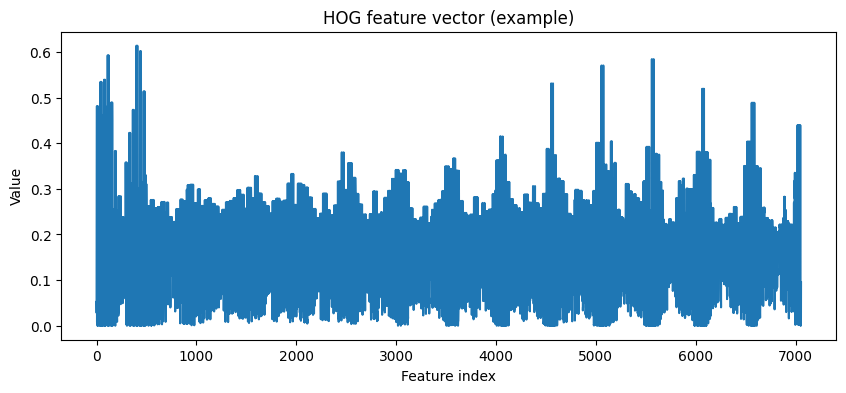

In [ ]:
# HOG Feature Extraction

import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import cv2
import matplotlib.pyplot as plt

from src.features.hog import extract_hog_dataset

from pathlib import Path

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = Path("results/feature_extraction")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

images = []
labels = []

for label, cls in enumerate(["normal", "tuberculosis"]):
    class_dir = DATA_DIR / cls

    for img_path in class_dir.iterdir():
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        images.append(img)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print(images.shape, labels.shape)

hog_features = extract_hog_dataset(images)
hog_features.shape

plt.figure(figsize=(10, 4))
plt.plot(hog_features[0])
plt.title("HOG feature vector (example)")
plt.xlabel("Feature index")
plt.ylabel("Value")
plt.savefig(
    RESULTS_DIR / "hog_feature_vector_example.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

k=1 | accuracy=0.8333
k=2 | accuracy=1.0000
k=3 | accuracy=0.8333
k=4 | accuracy=0.8333
k=5 | accuracy=0.8333
k=6 | accuracy=0.8333
k=7 | accuracy=0.8333
k=8 | accuracy=0.8333
k=9 | accuracy=0.8333
k=10 | accuracy=0.8333


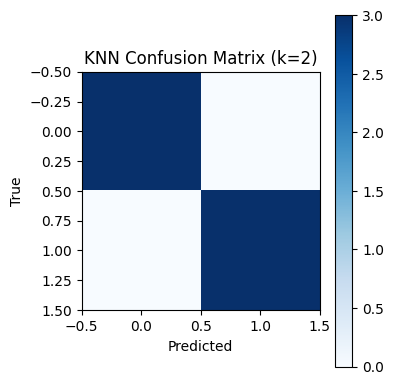

In [ ]:
# KNN 

import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

from sklearn.model_selection import train_test_split

from src.models.knn import train_knn, evaluate_knn

hog_features.shape  # (N, D)
labels.shape        # (N,)

X_train, X_test, y_train, y_test = train_test_split(
    hog_features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# Train KNN for multiple K
k_values = [1, 3, 5, 7, 9] # k1
#k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10 ] k2
results = []

for k in k_values:
    model = train_knn(X_train, y_train, k=k)
    metrics = evaluate_knn(model, X_test, y_test)

    results.append({
        "k": k,
        "accuracy":float(metrics["accuracy"]),
        "confusion_matrix": metrics["confusion_matrix"].tolist()
    })

    print(f"k={k} | accuracy={metrics['accuracy']:.4f}")


# Save results
RESULTS_DIR = Path("results/feature_extraction")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(RESULTS_DIR / "knn_results.json", "w") as f:
    json.dump(results, f, indent=2)


# Plot matrix
best = max(results, key=lambda x: x["accuracy"])
cm = best["confusion_matrix"]

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title(f"KNN Confusion Matrix (k={best['k']})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / f"knn_confusion_matrix_k{best['k']}.png",
    dpi=300
)
plt.show()


In [ ]:
# Decision Three